In [1]:
import pandas as pd
import numpy as np
from biom import load_table
from sklearn.decomposition import PCA, SparsePCA, IncrementalPCA
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, SubsetRandomSampler, Subset
from torch import optim
from TRPCA import trpca, utils
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm
import gc
from scipy.stats import ttest_ind
from itertools import combinations

In [2]:
table = pd.read_csv('data/control.csv', index_col=0)
age_metadata = pd.read_csv('data/sampleMetadata.csv', index_col='sample_id', dtype={'age': float})
shared_index = table.index.intersection(age_metadata.loc[(age_metadata.age.notna())&(age_metadata.body_site=='stool')].index)
table = table.loc[shared_index].drop(columns=['study_name','study_condition','subject_id'])
age_metadata = age_metadata.loc[shared_index]

table = (table*1000).round().astype(int)
df1 = np.log(table+1)

/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_60848/1648438879.py:2: DtypeWarning: Columns (21,22,25,28,29,30,32,33,35,38,51,52,53,54,55,56,57,58,63,64,65,67,68,69,74,75,76,80,90,91,92,93,96,104,105,108,109,111,112,116,117,118,119,120,121,126,128,129,134) have mixed types. Specify dtype option on import or set low_memory=False.
  age_metadata = pd.read_csv('data/sampleMetadata.csv', index_col='sample_id', dtype={'age': float})


In [3]:
n_dimensions = 256
# # # # # # Preprocess with PCA (Re-using the PCA application code from earlier)
X1_reduced, pca1 = utils.apply_pca(df1, n_dimensions) 
df = pd.DataFrame(X1_reduced, index=df1.index)

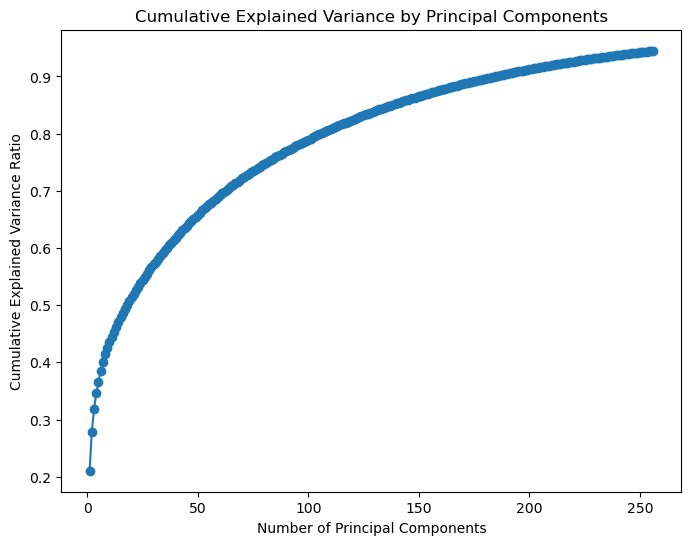

In [4]:
cum_explained_variance_ratio = np.cumsum(pca1.explained_variance_ratio_)

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cum_explained_variance_ratio) + 1), cum_explained_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance by Principal Components')
plt.show()

In [5]:
df['age'] = age_metadata.loc[age_metadata.index.isin(df.index)].age
df = df.loc[df.age.notna()]

In [6]:
age_metadata = age_metadata.loc[df.index]

In [8]:
# Parameters
num_folds = 5
batch_size = 1024
epochs = 2000

# K-Fold Cross-Validator
kf = GroupKFold(n_splits=num_folds)
# kf = KFold(n_splits=num_folds)
# Prepare full dataset (no split into train/test yet)
X = torch.tensor(df.drop(columns=['age']).to_numpy(), dtype=torch.float32)
y = torch.tensor(df.age.astype(float).to_numpy(), dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X, y)
subjects = age_metadata.subject_id
original_indices = age_metadata.index.tolist()
# Loss function, model instantiation, etc., outside the loop
criterion = nn.L1Loss()

# Dictionary to store the test indices and their corresponding predictions and true values
test_predictions = {}
fold_performance = []
# Cross-validation starts add y=y for kf split
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset, groups=subjects)):
    print(f'Fold {fold+1}/{num_folds}')
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    # DataLoaders using the subsets directly
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)  # Shuffle here if needed
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    # Reinitialize the model for each fold
    regression_model = trpca.TransformerRegressionModel(feature_size=n_dimensions, num_transformer_layers=3, nhead=8, dim_feedforward=2048, dropout=0.2, fast_transformer=True)
    optimizer = optim.SGD(regression_model.parameters(), lr=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=0)
    device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
    regression_model.to(device)

    best_valid_loss = float('inf')  # Initialize the best validation loss for the fold
    best_train_loss_at_best_val = None  # Track training loss when best validation loss occurs

    # Training and validation loop
    for epoch in tqdm(range(epochs), total=len(range(epochs))):
        # Training Phase
        regression_model.train()
        train_loss = 0
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = regression_model(batch_features)
            loss = criterion(outputs['regression_output'], batch_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_features.size(0)

        train_loss /= len(train_idx)

        # Validation Phase
        regression_model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                outputs = regression_model(batch_features)
                loss = criterion(outputs['regression_output'], batch_labels)
                valid_loss += loss.item() * batch_features.size(0)

        valid_loss /= len(val_idx)

        # Epoch ends
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {valid_loss:.4f}')
        scheduler.step()
        # At the end of each epoch, evaluate on validation set
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_train_loss_at_best_val = train_loss

            # Save predictions for this fold
            all_preds = []
            all_y_true = []
            with torch.no_grad():
                for batch_features, batch_labels in val_loader:
                    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                    outputs = regression_model(batch_features)
                    all_preds.extend(outputs['regression_output'].cpu().numpy())
                    all_y_true.extend(batch_labels.cpu().numpy())

            # # Update test predictions dictionary
            # test_predictions.update({idx: (pred, true) for idx, pred, true in zip(val_idx, all_preds, all_y_true)})
            # Map the integer indices back to the original string indices
            original_val_indices = [original_indices[i] for i in val_idx]

            # Update test predictions dictionary using original indices
            test_predictions.update({orig_idx: (pred, true) for orig_idx, pred, true in zip(original_val_indices, all_preds, all_y_true)})

    # Store the best validation loss of this fold and its associated training loss
    print(f"Best loss: {best_valid_loss}")  
    fold_performance.append((best_train_loss_at_best_val, best_valid_loss))
    torch.mps.empty_cache()
    gc.collect()
# Finalize cross-validation
print("K-Fold Cross-Validation completed.")
print("Best training and validation losses for each fold:", fold_performance)

### Step 2: Plot the Predictions

# Extract the indices and predictions
indices = list(test_predictions.keys())
predictions = [test_predictions[idx][0] for idx in indices]
true_values = [test_predictions[idx][1] for idx in indices]

Fold 1/5


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 30.6076, Val Loss: 30.1938
Epoch 2/2000, Train Loss: 29.8191, Val Loss: 28.7406
Epoch 3/2000, Train Loss: 26.4918, Val Loss: 18.6272
Epoch 4/2000, Train Loss: 14.4703, Val Loss: 12.8871
Epoch 5/2000, Train Loss: 12.7899, Val Loss: 12.6228
Epoch 6/2000, Train Loss: 12.5161, Val Loss: 12.5369
Epoch 7/2000, Train Loss: 12.3580, Val Loss: 12.3745
Epoch 8/2000, Train Loss: 12.2244, Val Loss: 12.3738
Epoch 9/2000, Train Loss: 12.1481, Val Loss: 12.3068
Epoch 10/2000, Train Loss: 12.1520, Val Loss: 12.2966
Epoch 11/2000, Train Loss: 12.0345, Val Loss: 12.2182
Epoch 12/2000, Train Loss: 11.6098, Val Loss: 12.1582
Epoch 13/2000, Train Loss: 12.7982, Val Loss: 11.3697
Epoch 14/2000, Train Loss: 11.0613, Val Loss: 12.1637
Epoch 15/2000, Train Loss: 11.6693, Val Loss: 11.2910
Epoch 16/2000, Train Loss: 10.8098, Val Loss: 11.4579
Epoch 17/2000, Train Loss: 11.3429, Val Loss: 10.7239
Epoch 18/2000, Train Loss: 10.4328, Val Loss: 10.8334
Epoch 19/2000, Train Loss: 10.2525, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 30.7098, Val Loss: 29.7357
Epoch 2/2000, Train Loss: 30.0345, Val Loss: 28.5272
Epoch 3/2000, Train Loss: 27.7302, Val Loss: 21.7369
Epoch 4/2000, Train Loss: 16.2420, Val Loss: 13.0761
Epoch 5/2000, Train Loss: 12.9071, Val Loss: 12.5667
Epoch 6/2000, Train Loss: 12.6893, Val Loss: 12.4365
Epoch 7/2000, Train Loss: 12.4563, Val Loss: 12.2440
Epoch 8/2000, Train Loss: 12.3182, Val Loss: 12.1230
Epoch 9/2000, Train Loss: 12.2027, Val Loss: 12.0844
Epoch 10/2000, Train Loss: 12.1814, Val Loss: 12.0845
Epoch 11/2000, Train Loss: 12.0256, Val Loss: 12.0187
Epoch 12/2000, Train Loss: 12.4037, Val Loss: 12.5193
Epoch 13/2000, Train Loss: 11.7848, Val Loss: 11.3000
Epoch 14/2000, Train Loss: 12.1781, Val Loss: 12.4742
Epoch 15/2000, Train Loss: 11.3367, Val Loss: 10.7600
Epoch 16/2000, Train Loss: 10.7935, Val Loss: 10.4574
Epoch 17/2000, Train Loss: 10.3529, Val Loss: 10.2689
Epoch 18/2000, Train Loss: 11.1914, Val Loss: 11.0458
Epoch 19/2000, Train Loss: 10.2143, V

...

Epoch 1/2000, Train Loss: 30.2767, Val Loss: 31.5473
Epoch 2/2000, Train Loss: 29.6333, Val Loss: 30.2968
Epoch 3/2000, Train Loss: 27.0861, Val Loss: 22.4820
Epoch 4/2000, Train Loss: 15.4182, Val Loss: 13.7251
Epoch 5/2000, Train Loss: 12.4873, Val Loss: 13.5369
Epoch 6/2000, Train Loss: 12.2520, Val Loss: 13.3981
Epoch 7/2000, Train Loss: 12.0212, Val Loss: 13.2250
Epoch 8/2000, Train Loss: 11.8468, Val Loss: 13.2336
Epoch 9/2000, Train Loss: 11.7854, Val Loss: 13.2008
Epoch 10/2000, Train Loss: 11.7643, Val Loss: 13.1741
Epoch 11/2000, Train Loss: 12.0174, Val Loss: 13.1263
Epoch 12/2000, Train Loss: 11.7913, Val Loss: 13.4878
Epoch 13/2000, Train Loss: 11.8664, Val Loss: 12.4237
Epoch 14/2000, Train Loss: 10.9071, Val Loss: 12.8673
Epoch 15/2000, Train Loss: 11.5206, Val Loss: 11.8320
Epoch 16/2000, Train Loss: 10.5218, Val Loss: 12.1933
Epoch 17/2000, Train Loss: 11.1507, Val Loss: 12.6660
Epoch 18/2000, Train Loss: 10.2464, Val Loss: 11.2797
Epoch 19/2000, Train Loss: 9.9075, Va

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 30.7525, Val Loss: 29.6921
Epoch 2/2000, Train Loss: 29.9778, Val Loss: 28.2140
Epoch 3/2000, Train Loss: 26.7094, Val Loss: 18.1400
Epoch 4/2000, Train Loss: 14.5750, Val Loss: 13.2024
Epoch 5/2000, Train Loss: 12.8150, Val Loss: 13.1068
Epoch 6/2000, Train Loss: 12.6175, Val Loss: 12.8444
Epoch 7/2000, Train Loss: 12.4824, Val Loss: 12.6250
Epoch 8/2000, Train Loss: 12.3516, Val Loss: 12.6602
Epoch 9/2000, Train Loss: 12.2535, Val Loss: 12.6346
Epoch 10/2000, Train Loss: 12.2237, Val Loss: 12.6342
Epoch 11/2000, Train Loss: 12.1104, Val Loss: 12.7873
Epoch 12/2000, Train Loss: 11.9217, Val Loss: 13.2894
Epoch 13/2000, Train Loss: 12.6142, Val Loss: 13.7724
Epoch 14/2000, Train Loss: 12.2541, Val Loss: 11.9895
Epoch 15/2000, Train Loss: 11.8537, Val Loss: 11.4725
Epoch 16/2000, Train Loss: 11.4362, Val Loss: 11.2777
Epoch 17/2000, Train Loss: 10.9422, Val Loss: 13.2881
Epoch 18/2000, Train Loss: 10.6223, Val Loss: 10.5667
Epoch 19/2000, Train Loss: 10.0630, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 30.6191, Val Loss: 30.0393
Epoch 2/2000, Train Loss: 29.8542, Val Loss: 28.6037
Epoch 3/2000, Train Loss: 26.6050, Val Loss: 18.1369
Epoch 4/2000, Train Loss: 14.4433, Val Loss: 12.1310
Epoch 5/2000, Train Loss: 12.7855, Val Loss: 11.8432
Epoch 6/2000, Train Loss: 12.4989, Val Loss: 11.6586
Epoch 7/2000, Train Loss: 12.2325, Val Loss: 11.5929
Epoch 8/2000, Train Loss: 12.1045, Val Loss: 11.4941
Epoch 9/2000, Train Loss: 12.0569, Val Loss: 11.4536
Epoch 10/2000, Train Loss: 11.9783, Val Loss: 11.4509
Epoch 11/2000, Train Loss: 11.9203, Val Loss: 11.2514
Epoch 12/2000, Train Loss: 12.7843, Val Loss: 11.0860
Epoch 13/2000, Train Loss: 11.4260, Val Loss: 11.9782
Epoch 14/2000, Train Loss: 12.3549, Val Loss: 10.9288
Epoch 15/2000, Train Loss: 11.2051, Val Loss: 11.4145
Epoch 16/2000, Train Loss: 11.7088, Val Loss: 10.3299
Epoch 17/2000, Train Loss: 10.3079, Val Loss: 10.2136
Epoch 18/2000, Train Loss: 10.6034, Val Loss: 12.2593
Epoch 19/2000, Train Loss: 10.4941, V

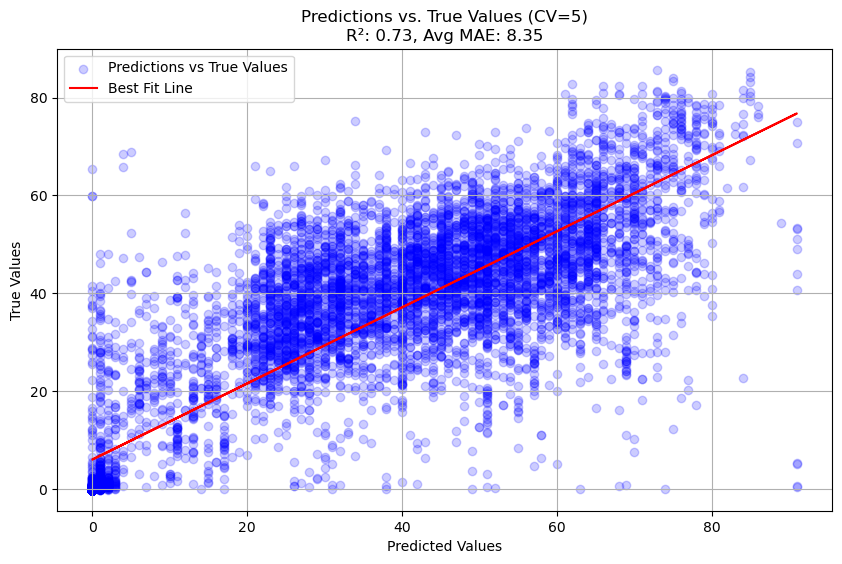

In [9]:
predictions = np.array(predictions)
true_values = np.array(true_values)

# Calculate R² and MAE
r2 = r2_score(true_values, predictions)
mae = mean_absolute_error(true_values, predictions)

# Calculate coefficients for the best fit line
slope, intercept = np.polyfit(true_values.reshape(-1), predictions.reshape(-1), 1)
best_fit_line = slope * true_values + intercept

plt.figure(figsize=(10, 6))
plt.scatter(true_values, predictions, color='blue', alpha=0.2, label='Predictions vs True Values')
plt.plot(true_values, best_fit_line, color='red', label='Best Fit Line')  # Plotting the best fit line
plt.title(f'Predictions vs. True Values (CV=5)\nR²: {r2:.2f}, Avg MAE: {mae:.2f}')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.legend()
plt.grid(True)  # Optional: Adds grid for better visualization
plt.show()

### Residual analysis for metadata categories. (sex, body site, diet, disease, country of birth, acne, antibiotics, etc. )

In [10]:
# Extract predictions, true values, and original indices
predictions = [pred for _, (pred, _) in test_predictions.items()]
true_values = [true for _, (_, true) in test_predictions.items()]
indices = list(test_predictions.keys())

# Step 1: Calculate the absolute error
absolute_errors = [(pred - true)[0] for pred, true in zip(predictions, true_values)]

# Step 2: Create a DataFrame with the errors and ensure it has a common index column
error_df = pd.DataFrame({'original_index': indices, 'absolute_error': absolute_errors})

# Ensure 'original_index' in error_df is of type string for merging
error_df['original_index'] = error_df['original_index'].astype(str)

# Step 3: Ensure age_metadata has an index column that matches the original indices
age_metadata['original_index'] = age_metadata.index.astype(str)

# Merge the DataFrames using the common column 'original_index'
merged_df = pd.merge(age_metadata, error_df, on='original_index', how='inner')

In [11]:
# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'
    
def plot_residual_violin(metadata_column, merged_df):
    plt.figure(figsize=(10, 10))
    ax = sns.violinplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", hue=metadata_column, legend=False)
    sns.stripplot(x=metadata_column, y='absolute_error', data=merged_df, color='k', alpha=0.05, jitter=True)
    plt.title(f'Violin Plot of Prediction Errors by {metadata_column}')
    plt.xlabel(metadata_column)
    plt.ylabel('Absolute Error')

    # Perform a statistical test between all groups
    group_combinations = list(combinations(merged_df[metadata_column].unique(), 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = merged_df['absolute_error'].max()
    y_min = merged_df['absolute_error'].min()
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis
    categories = merged_df[metadata_column].unique()
    category_positions = {category: i for i, category in enumerate(categories)}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.show()

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind
import numpy as np

# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def plot_residual_distribution(metadata_column, merged_df):
    plt.figure(figsize=(10, 10))

    # Plot distributions
    categories = merged_df[metadata_column].unique()
    colors = sns.color_palette("muted", len(categories))
    
    for category, color in zip(categories, colors):
        subset = merged_df[merged_df[metadata_column] == category]
        sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)
    
    plt.title(f'Distribution of Prediction Errors by {metadata_column}')
    plt.xlabel('Absolute Error')
    plt.ylabel('Density')

    # Perform a statistical test between all groups
    group_combinations = list(combinations(categories, 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = 0.06  # Density plots typically max out at 1
    y_min = 0
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis for annotations
    category_positions = {category: np.mean(merged_df[merged_df[metadata_column] == category]['absolute_error']) for category in categories}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.legend(title=metadata_column)
    plt.show()

# Example usage:
# plot_residual_distribution('your_metadata_column', your_merged_df)


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind
import numpy as np

# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def plot_residual_boxplot(metadata_column, merged_df):
    plt.figure(figsize=(8, 8))

    # Plot boxplot
    ax = sns.boxplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", showfliers=False)
    sns.stripplot(x=metadata_column, y='absolute_error', data=merged_df, color='k', alpha=0.5, jitter=True)

    plt.title(f'Boxplot of Prediction Errors by {metadata_column}')
    plt.xlabel(metadata_column)
    plt.ylabel('Absolute Error')

    # Perform a statistical test between all groups
    categories = merged_df[metadata_column].unique()
    group_combinations = list(combinations(categories, 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = merged_df['absolute_error'].max()
    y_min = merged_df['absolute_error'].min()
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis
    category_positions = {category: i for i, category in enumerate(categories)}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.show()

# Example usage:
# plot_residual_boxplot('your_metadata_column', your_merged_df)


In [13]:
age_metadata

,study_name,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,infant_age,age_category,gender,...,hla_dqa11,hla_drb11,zigosity,brinkman_index,alcohol_numeric,breastfeeding_duration,formula_first_day,ALT,eGFR,original_index
MV_FEI1_t1Q14,AsnicarF_2017,MV_FEI1,stool,NaN,control,healthy,0.0,90.0,newborn,female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MV_FEI1_t1Q14
MV_FEI2_t1Q14,AsnicarF_2017,MV_FEI2,stool,NaN,control,healthy,0.0,90.0,newborn,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MV_FEI2_t1Q14
MV_FEI3_t1Q14,AsnicarF_2017,MV_FEI3,stool,NaN,control,healthy,0.0,90.0,newborn,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MV_FEI3_t1Q14
MV_FEI4_t1Q14,AsnicarF_2017,MV_FEI4,stool,NaN,control,healthy,1.0,NaN,child,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MV_FEI4_t1Q14
MV_FEI4_t2Q15,AsnicarF_2017,MV_FEI4,stool,NaN,control,healthy,1.0,NaN,child,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MV_FEI4_t2Q15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wHAXPI034920-8,ZhuF_2020,wHAXPI034920-8,stool,no,control,healthy,21.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wHAXPI034920-8
wHAXPI034921-9,ZhuF_2020,wHAXPI034921-9,stool,no,control,healthy,23.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wHAXPI034921-9
wHAXPI034922-11,ZhuF_2020,wHAXPI034922-11,stool,no,control,healthy,21.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wHAXPI034922-11
wHAXPI034923-12,ZhuF_2020,wHAXPI034923-12,stool,no,control,healthy,22.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wHAXPI034923-12


In [14]:
# Function to check if a column has significant results
def check_significance(metadata_column, merged_df):
    merged_df = merged_df.dropna(subset=[metadata_column])
    if len(merged_df[metadata_column].unique())<10:
        # Perform a statistical test between all groups
        group_combinations = list(combinations(merged_df[metadata_column].unique(), 2))
        for comb in group_combinations:
            group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
            group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
            t_stat, p_val = ttest_ind(group1, group2)
            if p_val < 0.05:
                return True
        return False
    else:
        return False
    
# Iterate through each column in age_metadata and run the analysis
significant_columns = []

for column in tqdm(age_metadata.columns, total=len(age_metadata.columns)):
    if check_significance(column, merged_df):
        significant_columns.append(column)

# Output the list of significant columns
print("Number of Significant columns:", len(significant_columns))

  0%|          | 0/141 [00:00<?, ?it/s]

Number of Significant columns: 15


/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_60848/2584679727.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t_stat, p_val = ttest_ind(group1, group2)
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_60848/2584679727.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may b

In [ ]:
# merged_df.to_csv('data/wgs_gut_residuals.tsv', sep='\t', index=True)

Comparison vegetarian vs vegan: p-value = 0.5299353319783968
Comparison vegetarian vs omnivore: p-value = 0.006046723725355441
Comparison vegan vs omnivore: p-value = 0.0012479631394803896


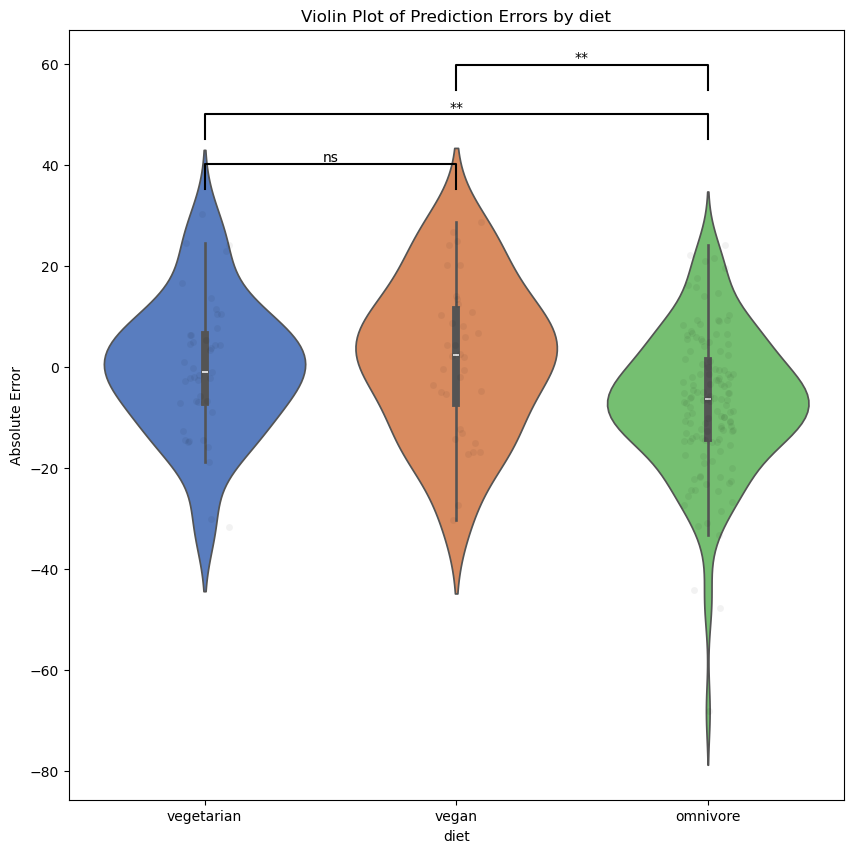

In [30]:
plot_residual_violin('diet', merged_df.loc[merged_df.diet.notna()])

Comparison vegetarian vs vegan: p-value = 0.5299353319783968
Comparison vegetarian vs omnivore: p-value = 0.006046723725355441
Comparison vegan vs omnivore: p-value = 0.0012479631394803896


/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_60848/4157708794.py:27: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_60848/4157708794.py:27: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_60848/4157708794.py:27: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)


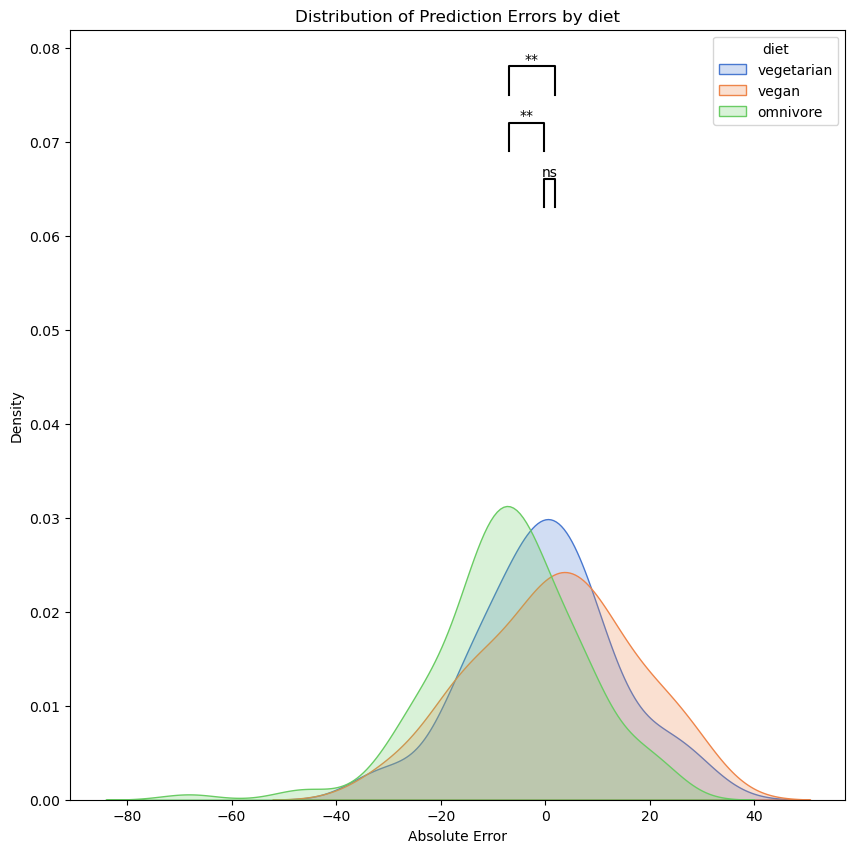

In [31]:
plot_residual_distribution('diet', merged_df.loc[merged_df.diet.notna()])

Comparison vegetarian vs vegan: p-value = 0.5299353319783968
Comparison vegetarian vs omnivore: p-value = 0.006046723725355441
Comparison vegan vs omnivore: p-value = 0.0012479631394803896


/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_60848/680936819.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", showfliers=False)


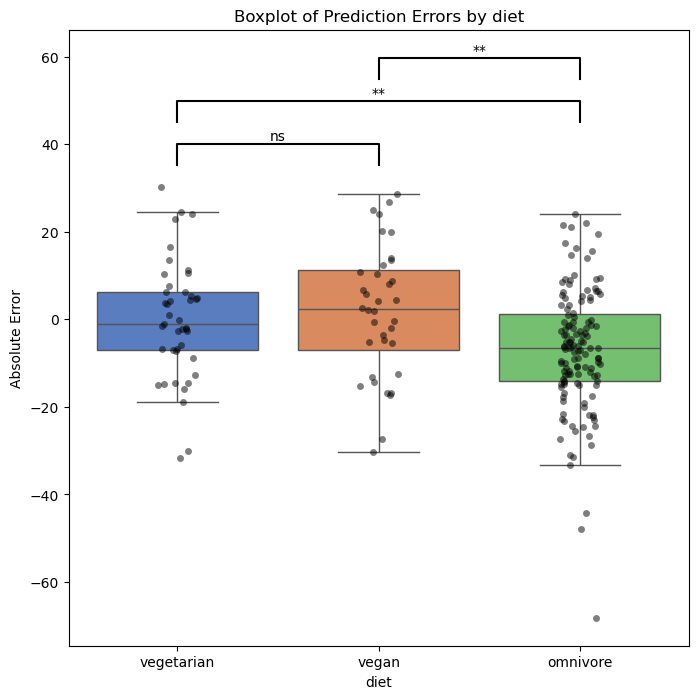

In [34]:
plot_residual_boxplot('diet', merged_df.loc[merged_df.diet.notna()])

In [ ]:
plot_residual_violin('cohort', merged_df.loc[merged_df.sex!='other'])

In [ ]:
plot_residual_violin('race', merged_df.loc[merged_df.race.notna()])

In [ ]:
plot_residual_violin('life_stage', merged_df.loc[merged_df.life_stage.notna()])